Nous commençons cet EDA par un nettoyage de notre dataset

In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

df= pd.read_csv(r"C:/Users/Paul Adrien/Documents/churn_pfe/dataset_pfe_brut.csv")
df.head()

,client_id,nom_client,genre_client,date_naissance,adresse_email,num_tel_mobile,adresse_physique,identifiant_national,type_abonnement,plan_tarifaire,...,satisfaction_manquante,nb_reclamations,reclamation_manquante,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
0,1,Client_1,Homme,1948-05-03,client_1@tunisietelecom.tn,21649985826,Adresse_1,2021469,Offre Prépayée,Forfait Mobile (Mixte),...,0,0.0,0,3.07,25.05,-87.74,1.1429,29.0322,1,0.0
1,2,Client_2,Homme,2002-03-03,client_2@outlook.fr,21624436252,Adresse_2,6779277,Offre à Facture,Offre Classique,...,0,NaN,1,0.00,0.00,0.00,1.0000,0.0000,6,NaN
2,3,Client_3,Homme,1957-12-19,client_3@outlook.fr,21691817052,Adresse_3,3892371,Offre Prépayée,Offre Classique,...,1,NaN,1,0.00,0.00,0.00,0.5000,0.0000,4,NaN
3,4,Client_4,Femme,1975-12-06,client_4@gmail.com,21648596585,Adresse_4,7970199,Offre Prépayée,Offre Classique,...,0,3.0,0,0.00,0.00,0.00,0.3000,0.0000,6,12.0
4,5,Client_5,Homme,1957-06-22,client_5@yahoo.com,21627269324,Adresse_5,11463001,Offre Prépayée,Offre Classique,...,0,6.0,0,0.00,0.00,0.00,0.3333,0.0000,6,30.0


In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  300 non-null    int64  
 1   nom_client                 300 non-null    object 
 2   genre_client               300 non-null    object 
 3   date_naissance             300 non-null    object 
 4   adresse_email              300 non-null    object 
 5   num_tel_mobile             300 non-null    int64  
 6   adresse_physique           300 non-null    object 
 7   identifiant_national       300 non-null    int64  
 8   type_abonnement            300 non-null    object 
 9   plan_tarifaire             300 non-null    object 
 10  date_debut_abonnement      300 non-null    object 
 11  statut_actif               300 non-null    bool   
 12  moyen_paiement             300 non-null    object 
 13  facture_moyenne_mensuelle  279 non-null    float64

In [316]:
df.describe()

,client_id,num_tel_mobile,identifiant_national,facture_moyenne_mensuelle,satisfaction_client,tenure_jours,tenure_mois,duree_appel_totale_sec,duree_appel_moyenne_sec,nb_appels,...,satisfaction_manquante,nb_reclamations,reclamation_manquante,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
count,300.000000,3.000000e+02,3.000000e+02,279.000000,282.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,252.000000,300.000000,300.000000,300.000000,290.000000,300.000000,298.000000,300.000000,252.000000
mean,150.500000,2.165740e+10,1.043652e+07,28.054014,2.446809,1060.263333,34.313333,1079.460000,158.298392,5.886667,...,0.060000,3.023810,0.160000,4.969233,4.596133,13.122034,1.477945,69.142106,6.106667,13.103175
std,86.746758,2.617726e+07,5.568964e+06,29.403601,1.398655,423.116200,13.863712,937.331968,109.891332,4.524237,...,0.237884,2.457493,0.367219,12.213920,15.702316,60.191916,3.675272,629.250777,2.577616,12.211828
min,1.000000,2.162144e+10,1.077175e+06,4.590000,1.000000,368.000000,12.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-93.680000,0.000000,0.000000,1.000000,0.000000
25%,75.750000,2.164178e+10,6.062496e+06,11.060000,1.000000,691.750000,22.000000,267.000000,98.037500,2.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.348000,0.000000,4.000000,3.000000
50%,150.500000,2.165154e+10,9.750397e+06,17.580000,2.000000,1042.000000,34.000000,918.500000,156.625000,6.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.666700,0.000000,6.000000,10.000000
75%,225.250000,2.169191e+10,1.508305e+07,33.415000,4.000000,1427.750000,46.000000,1693.000000,214.333333,10.000000,...,0.000000,5.000000,0.000000,4.177500,1.932500,0.000000,1.000000,13.086400,9.000000,20.000000
max,300.000000,2.169984e+10,1.995067e+07,145.560000,5.000000,1826.000000,59.000000,5036.000000,861.000000,21.000000,...,1.000000,13.000000,1.000000,84.720000,210.780000,200.000000,20.000000,10257.920000,9.000000,65.000000


In [317]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_array = df[num_features].fillna(0).values.astype(np.float64)
n = num_array.shape[0]

vif_results = []
for i, col in enumerate(num_features):
    others = [j for j in range(len(num_features)) if j != i]
    X_others = num_array[:, others]
    y_col = num_array[:, i]

    # Régression OLS : X_j ~ autres variables
    X_design = np.column_stack([np.ones(n), X_others])
    coef, _, _, _ = np.linalg.lstsq(X_design, y_col, rcond=None)
    y_pred = X_design @ coef

    ss_tot = np.sum((y_col - y_col.mean()) ** 2)
    ss_res = np.sum((y_col - y_pred) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    vif = round(1 / (1 - r2) if r2 < 1 else float("inf"), 2)

    vif_results.append({
        "Variable": col,
        "VIF": vif,
        "Décision": "Multicolinéaire" if vif > 10 else "Acceptable"
    })

vif_df = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))


                 Variable     VIF        Décision
              tenure_mois 2621.34 Multicolinéaire
             tenure_jours 2618.63 Multicolinéaire
        longitude_moyenne  103.08 Multicolinéaire
         latitude_moyenne  101.65 Multicolinéaire
        score_frustration   40.96 Multicolinéaire
          nb_reclamations   39.16 Multicolinéaire
           data_totale_gb   14.97 Multicolinéaire
      nb_evenements_total   10.81 Multicolinéaire
   duree_appel_totale_sec    9.77      Acceptable
                nb_appels    9.73      Acceptable
          data_moyenne_gb    8.50      Acceptable
 duree_session_totale_sec    6.75      Acceptable
              nb_sessions    6.17      Acceptable
   nb_evenements_data_cdr    5.58      Acceptable
              data_mois_M    3.77      Acceptable
duree_session_moyenne_sec    3.36      Acceptable
  duree_appel_moyenne_sec    3.04      Acceptable
                sms_total    2.86      Acceptable
      satisfaction_client    2.82      Acceptable


In [318]:
# Groupe 1 — Identifiants et données administratives
# Ne portent aucune information prédictive
cols_admin = [
    'client_id',              # identifiant unique, non prédictif
    'nom_client',             # donnée nominative
    'adresse_email',          # donnée nominative
    'num_tel_mobile',         # donnée nominative
    'adresse_physique',       # donnée nominative
    'identifiant_national',   # donnée nominative
    'date_naissance',         # remplacée par tenure_jours
    'date_debut_abonnement',  # remplacée par tenure_jours
    'date_consentement',      # date brute, non prédictive
    'latitude_moyenne',       # coordonnée brute → remplacée par zone_reseau_principale
    'longitude_moyenne',      # coordonnée brute → remplacée par zone_reseau_principale
]

# Groupe 4 — Redondance totale/moyenne (NEW)
# total = moyenne × compteur, or les compteurs sont déjà exclus (VIF)
# Garder le total reviendrait à réintroduire ces compteurs implicitement
cols_redondance_totale = [
    'duree_appel_totale_sec',    # = duree_appel_moyenne_sec × nb_appels (exclu)
    'data_totale_gb',            # = data_moyenne_gb × nb_mois (tenure exclu)
    'duree_session_totale_sec',  # = duree_session_moyenne_sec × nb_sessions (exclu)
    'duree_session_totale_sec',

]

# Groupe 2 — Data leakage
# Variable utilisée pour CONSTRUIRE la cible churn (recence >= 90j)
# L'inclure dans X reviendrait à donner la réponse au modèle
cols_leakage = [
    'recence_cdr_jours',      # définit churn=1 si >= 90j — data leakage direct
]

# Groupe 3 — Colonnes dérivées redondantes (VIF > 10)
# Ces colonnes sont des combinaisons exactes d'autres colonnes déjà présentes
cols_vif = [
    'tenure_jours',            # = tenure_jours / 30.44 — doublon exact
    'nb_appels',              # absorbé par ratio_sms_appels
    'sms_total',              # absorbé par ratio_sms_appels
    'nb_evenements_data_cdr', # composante de nb_evenements_total
    'nb_reclamations',        # absorbé par score_frustration
]

# ── Construction de X et y ────────────────────────────────────────
cols_a_exclure = (cols_admin + cols_leakage + cols_vif + cols_redondance_totale )

# statut_actif exclu aussi : variable administrative liée au contrat,
# pas un comportement observable en temps réel
cols_a_exclure += ['statut_actif']

X = df.drop(columns=[c for c in cols_a_exclure if c in df.columns])
y = df['churn']

print(f"Features retenues : {X.shape[1]}")
print(f"Variable cible    : churn ({y.sum()} churné / {len(y)} total)")
print(f"\nFeatures X :")
for c in X.columns:
    print(f"  {c}")

Features retenues : 29
Variable cible    : churn (83 churné / 300 total)

Features X :
  genre_client
  type_abonnement
  plan_tarifaire
  moyen_paiement
  facture_moyenne_mensuelle
  satisfaction_client
  consentement_marketing
  optout_marketing
  tenure_mois
  duree_appel_moyenne_sec
  data_moyenne_gb
  nb_evenements_total
  nb_sessions
  duree_session_moyenne_sec
  taux_cookies
  recence_session_jours
  zone_reseau_principale
  qualite_signal_dominante
  churn
  data_manquante
  satisfaction_manquante
  reclamation_manquante
  data_mois_M
  data_mois_M1
  tendance_data_pct
  ratio_sms_appels
  ratio_data_voix
  score_qualite_zone
  score_frustration


In [319]:
import os
desktop_path = os.path.join(os.environ['USERPROFILE'], 'Desktop', 'dataset_selected_features_clean_v3.csv')

df.to_csv(desktop_path, index=False)
print(f"Fichier propre exporté sur le bureau : {desktop_path}")

Fichier propre exporté sur le bureau : C:\Users\Paul Adrien\Desktop\dataset_selected_features_clean_v3.csv


Dans un premer temps, nous procèderons à une analyse univariée


In [320]:
import seaborn as sns

data = pd.read_csv('dataset_selected_features_clean_v3.csv')
data.head()

,client_id,nom_client,genre_client,date_naissance,adresse_email,num_tel_mobile,adresse_physique,identifiant_national,type_abonnement,plan_tarifaire,...,satisfaction_manquante,nb_reclamations,reclamation_manquante,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
0,1,Client_1,Homme,1948-05-03,client_1@tunisietelecom.tn,21649985826,Adresse_1,2021469,Offre Prépayée,Forfait Mobile (Mixte),...,0,0.0,0,3.07,25.05,-87.74,1.1429,29.0322,1,0.0
1,2,Client_2,Homme,2002-03-03,client_2@outlook.fr,21624436252,Adresse_2,6779277,Offre à Facture,Offre Classique,...,0,NaN,1,0.00,0.00,0.00,1.0000,0.0000,6,NaN
2,3,Client_3,Homme,1957-12-19,client_3@outlook.fr,21691817052,Adresse_3,3892371,Offre Prépayée,Offre Classique,...,1,NaN,1,0.00,0.00,0.00,0.5000,0.0000,4,NaN
3,4,Client_4,Femme,1975-12-06,client_4@gmail.com,21648596585,Adresse_4,7970199,Offre Prépayée,Offre Classique,...,0,3.0,0,0.00,0.00,0.00,0.3000,0.0000,6,12.0
4,5,Client_5,Homme,1957-06-22,client_5@yahoo.com,21627269324,Adresse_5,11463001,Offre Prépayée,Offre Classique,...,0,6.0,0,0.00,0.00,0.00,0.3333,0.0000,6,30.0


In [321]:
# Conversion des valeurs 'Yes' et 'No' en 1 et 0 pour les colonnes catégoriques binaires
# Remplacement des espaces vides par NaN (valeurs manquantes)
data.replace({'Yes': 1, 'No': 0, ' ': np.nan}, inplace=True)

In [322]:
# Obtenir un résumé des colonnes, types et valeurs manquantes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  300 non-null    int64  
 1   nom_client                 300 non-null    object 
 2   genre_client               300 non-null    object 
 3   date_naissance             300 non-null    object 
 4   adresse_email              300 non-null    object 
 5   num_tel_mobile             300 non-null    int64  
 6   adresse_physique           300 non-null    object 
 7   identifiant_national       300 non-null    int64  
 8   type_abonnement            300 non-null    object 
 9   plan_tarifaire             300 non-null    object 
 10  date_debut_abonnement      300 non-null    object 
 11  statut_actif               300 non-null    bool   
 12  moyen_paiement             300 non-null    object 
 13  facture_moyenne_mensuelle  279 non-null    float64

Nous relèverons ici les indicatuers de positions et tendances centrales


In [323]:
# Calculer des statistiques descriptives pour les colonnes numériques
num = ['facture_moyenne_mensuelle', 
    'satisfaction_client', 
    'tenure_mois',  
    'duree_appel_moyenne_sec',  
    'data_moyenne_gb', 
    'nb_evenements_total', 
    'nb_sessions', 
    'duree_session_moyenne_sec',  
    'taux_cookies',  
    'data_mois_M', 
    'data_mois_M1', 
    'tendance_data_pct', 
    'ratio_sms_appels', 
    'ratio_data_voix', 
    'score_qualite_zone', 
    'score_frustration']   #toutes les variables flag étant exclues, de même que la variable cible accompagnée de recence_cdr_jours, et celles decouvertent plus trad 
data[num].describe(percentiles=np.arange(0.1, 1, 0.1))

,facture_moyenne_mensuelle,satisfaction_client,tenure_mois,duree_appel_moyenne_sec,data_moyenne_gb,nb_evenements_total,nb_sessions,duree_session_moyenne_sec,taux_cookies,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
count,279.000000,282.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,290.000000,300.000000,298.000000,300.000000,252.000000
mean,28.054014,2.446809,34.313333,158.298392,4.701405,17.960000,6.123333,313.070342,0.616721,4.969233,4.596133,13.122034,1.477945,69.142106,6.106667,13.103175
std,29.403601,1.398655,13.863712,109.891332,9.778455,12.424423,3.744533,208.454379,0.321615,12.213920,15.702316,60.191916,3.675272,629.250777,2.577616,12.211828
min,4.590000,1.000000,12.000000,0.000000,0.000000,0.000000,1.000000,30.000000,0.000000,0.000000,0.000000,-93.680000,0.000000,0.000000,1.000000,0.000000
10%,6.986000,1.000000,15.900000,0.000000,0.000000,3.000000,1.000000,105.771429,0.100000,0.000000,0.000000,-16.774000,0.000000,0.000000,2.000000,0.000000
20%,9.644000,1.000000,21.000000,79.133333,0.000000,5.000000,2.000000,147.666667,0.333333,0.000000,0.000000,0.000000,0.300000,0.000000,4.000000,2.000000
30%,12.692000,1.000000,24.700000,116.746667,0.000000,8.700000,3.000000,189.841667,0.428571,0.000000,0.000000,0.000000,0.416700,0.000000,4.000000,4.000000
40%,14.730000,2.000000,29.000000,137.133333,0.000000,15.000000,5.000000,221.600000,0.565079,0.000000,0.000000,0.000000,0.500000,0.000000,6.000000,8.000000
50%,17.580000,2.000000,34.000000,156.625000,0.000000,18.000000,6.000000,267.862500,0.666667,0.000000,0.000000,0.000000,0.666700,0.000000,6.000000,10.000000
60%,21.196000,2.000000,38.000000,178.100000,0.000000,20.000000,7.000000,313.109091,0.750000,0.000000,0.000000,0.000000,0.880560,0.000000,6.000000,13.800000


"L'analyse des tendances centrales révèle une distribution bimodale ou fortement asymétrique sur les variables de consommation (Data, Appels). Cela est dû à la présence de zéros structurels liés aux contraintes des offres (ex: 0 data pour l'Offre Classique). En conséquence, les moyennes globales ne doivent pas être interprétées comme le comportement d'un 'client moyen', mais comme le résultat d'un mélange de segments d'offres distincts."

In [333]:
# === ZÉROS STRUCTURELS : diagnostic par offre ===

features_offre_dependantes = {
    'data': ['data_moyenne_gb', 'ratio_data_voix', 'tendance_data_pct'],
    'voix_sms': ['duree_appel_moyenne_sec', 'ratio_sms_appels']
}

print("=" * 60)
print("DIAGNOSTIC ZÉROS STRUCTURELS PAR TYPE D'ABONNEMENT")
print("=" * 60)

for groupe, cols in features_offre_dependantes.items():
    print(f"\n--- Groupe : {groupe} ---")
    for col in cols:
        if col in df.columns:
            n_zeros = (df[col] == 0).sum()
            pct_zeros = n_zeros / len(df) * 100
            print(f"  {col:35s} → {n_zeros:3d} zéros ({pct_zeros:.1f}%)")

# Croiser avec le type d'abonnement
print("\n\n--- Proportion de zéros data_moyenne_gb par type_abonnement ---")
if 'type_abonnement' in df.columns and 'data_moyenne_gb' in df.columns:
    print(df.groupby('type_abonnement')['data_moyenne_gb'].apply(
        lambda x: f"{(x == 0).sum()}/{len(x)} zéros ({(x == 0).mean()*100:.1f}%)"
    ).to_string())

DIAGNOSTIC ZÉROS STRUCTURELS PAR TYPE D'ABONNEMENT

--- Groupe : data ---
  data_moyenne_gb                     → 212 zéros (70.7%)
  ratio_data_voix                     → 213 zéros (71.0%)
  tendance_data_pct                   → 212 zéros (70.7%)

--- Groupe : voix_sms ---
  duree_appel_moyenne_sec             →  42 zéros (14.0%)
  ratio_sms_appels                    →  46 zéros (15.3%)


--- Proportion de zéros data_moyenne_gb par type_abonnement ---
type_abonnement
Offre Prépayée     176/248 zéros (71.0%)
Offre à Facture      36/52 zéros (69.2%)


In [334]:
# === STATISTIQUES CONDITIONNELLES (sans mélanger les offres) ===

cols_data = [ 'data_moyenne_gb', 'ratio_data_voix']
cols_voix = [ 'duree_appel_moyenne_sec', 'ratio_sms_appels']

print("Statistiques data_totale_mb — clients avec data uniquement (> 0) :")
mask_data = df['data_totale_gb'] > 0
print(df.loc[mask_data, cols_data].describe(percentiles=[.25, .5, .75]).round(2))

print("\nStatistiques duree_appel — clients avec appels uniquement (> 0) :")
mask_voix = df['duree_appel_totale_sec'] > 0
print(df.loc[mask_voix, cols_voix].describe(percentiles=[.25, .5, .75]).round(2))

Statistiques data_totale_mb — clients avec data uniquement (> 0) :
       data_moyenne_gb  ratio_data_voix
count            85.00            85.00
mean             16.01           242.40
std              12.10          1165.11
min               2.77             3.42
25%               7.47            24.61
50%              12.49            76.89
75%              21.36           100.00
max              57.46         10257.92

Statistiques duree_appel — clients avec appels uniquement (> 0) :
       duree_appel_moyenne_sec  ratio_sms_appels
count                   258.00            258.00
mean                    184.07              0.87
std                      96.37              0.63
min                       4.00              0.00
25%                     126.38              0.44
50%                     173.87              0.78
75%                     227.76              1.00
max                     861.00              3.50


Analyse des moyennes par Churn Nous calculons les moyennes des colonnes numériques en fonction de la variable Churn. Cela permet d’observer les différences de comportement entre les clients qui résilient et ceux qui restent.

In [335]:
data.groupby('churn')[num].mean()

,facture_moyenne_mensuelle,satisfaction_client,tenure_mois,duree_appel_moyenne_sec,data_moyenne_gb,nb_evenements_total,nb_sessions,duree_session_moyenne_sec,taux_cookies,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
churn,,,,,,,,,,,,,,,,
0,24.885528,2.674757,36.834101,156.922135,5.74720,21.188940,6.903226,318.023106,0.619776,6.097926,6.062995,16.248626,0.940824,72.324979,6.078341,11.108108
1,35.935625,1.828947,27.722892,161.896559,1.96722,9.518072,4.084337,300.121549,0.608736,2.018313,0.761084,4.771266,2.882225,60.897316,6.180723,18.611940


In [338]:
# === STATISTIQUES DESCRIPTIVES PAR STATUT CHURN ===

num = ['facture_moyenne_mensuelle', 
    'satisfaction_client', 
    'tenure_mois',  
    'duree_appel_moyenne_sec',  
    'data_moyenne_gb', 
    'nb_evenements_total', 
    'nb_sessions', 
    'duree_session_moyenne_sec',  
    'taux_cookies',  
    'data_mois_M', 
    'data_mois_M1', 
    'tendance_data_pct', 
    'ratio_sms_appels', 
    'ratio_data_voix', 
    'score_qualite_zone', 
    'score_frustration']

stats = df.groupby('churn')[num].agg([ 'std', 'var']).round(3)

print("\n ÉCART-TYPE")
print(df.groupby('churn')[num].std().round(3).T.to_string())

print("\n VARIANCE")
print(df.groupby('churn')[num].var().round(3).T.to_string())


 ÉCART-TYPE
churn                            0        1
facture_moyenne_mensuelle   26.300   34.938
satisfaction_client          1.427    1.112
tenure_mois                 13.391   12.950
duree_appel_moyenne_sec    102.059  128.756
data_moyenne_gb             10.558    6.674
nb_evenements_total         12.364    7.775
nb_sessions                  3.616    3.295
duree_session_moyenne_sec  205.349  217.103
taux_cookies                 0.295    0.384
data_mois_M                 13.675    6.260
data_mois_M1                18.173    2.911
tendance_data_pct           68.568   25.864
ratio_sms_appels             1.952    6.038
ratio_data_voix            699.553  396.098
score_qualite_zone           2.633    2.440
score_frustration           11.404   12.753

 VARIANCE
churn                               0           1
facture_moyenne_mensuelle     691.675    1220.656
satisfaction_client             2.035       1.237
tenure_mois                   179.315     167.715
duree_appel_moyenne_sec     

Le choc de l'Écart-Type (Std) vs La Moyenne
En statistiques, quand l'écart-type est supérieur à la moyenne, on parle d'une dispersion extrême. C'est exactement ce qui se passe ici.

Forfait Illimité : Moyenne de 33.52 € avec un écart-type de 38.25 €.

vForfait Mobile (Mixte) : Moyenne 24.55 €, écart-type 27.72 €.

In [339]:
data.groupby('plan_tarifaire')[num].mean()

,facture_moyenne_mensuelle,satisfaction_client,tenure_mois,duree_appel_moyenne_sec,data_moyenne_gb,nb_evenements_total,nb_sessions,duree_session_moyenne_sec,taux_cookies,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
plan_tarifaire,,,,,,,,,,,,,,,,
Forfait Illimité,32.518800,2.880000,33.962963,0.000000,28.804013,36.333333,6.074074,297.475926,0.696032,26.061852,26.883333,37.16640,0.000000,96.296296,5.481481,10.083333
Forfait Mobile (Mixte),23.582881,2.396825,32.859375,173.202741,9.886144,21.265625,5.296875,324.685983,0.634440,12.298438,10.202969,51.36125,1.184112,290.392705,6.046875,14.534483
Offre Classique,28.834410,2.407216,34.803828,174.184413,0.000000,14.574163,6.382775,311.527989,0.601050,0.000000,0.000000,0.00000,1.758853,0.000000,6.205742,13.041176


In [329]:
data.groupby('type_abonnement')[num].mean()

,facture_moyenne_mensuelle,satisfaction_client,tenure_mois,duree_appel_moyenne_sec,data_moyenne_gb,nb_evenements_total,nb_sessions,duree_session_moyenne_sec,taux_cookies,data_mois_M,data_mois_M1,tendance_data_pct,ratio_sms_appels,ratio_data_voix,score_qualite_zone,score_frustration
type_abonnement,,,,,,,,,,,,,,,,
Offre Prépayée,27.544693,2.508475,34.241935,159.673762,4.389618,18.241935,6.370968,305.280396,0.622209,4.692258,4.494637,13.2725,1.494539,79.845893,6.108871,12.274882
Offre à Facture,30.330980,2.130435,34.653846,151.738938,6.188389,16.615385,4.942308,350.222393,0.590552,6.290192,5.080192,12.3998,1.398806,17.302200,6.096154,17.365854


In [340]:
data.groupby("plan_tarifaire")["churn"].value_counts(normalize=True)*100

plan_tarifaire          churn
Forfait Illimité        0        96.296296
                        1         3.703704
Forfait Mobile (Mixte)  0        79.687500
                        1        20.312500
Offre Classique         0        66.985646
                        1        33.014354
Name: proportion, dtype: float64

In [341]:
# ── Calcul de l'ARPU par Plan et par Churn ──────────────────────────────────
arpu_stats = data.groupby(['plan_tarifaire', 'churn'])['facture_moyenne_mensuelle'].mean().unstack()

# Renommer les colonnes pour plus de clarté
arpu_stats.columns = ['ARPU_Fidèles', 'ARPU_Churneurs']

# Calculer l'écart en %
arpu_stats['Ecart_Pct'] = round(
    (arpu_stats['ARPU_Churneurs'] - arpu_stats['ARPU_Fidèles']) / arpu_stats['ARPU_Fidèles'] * 100, 2
)

print("Analyse de la perte de revenu (ARPU) :")
print(arpu_stats)

Analyse de la perte de revenu (ARPU) :
                        ARPU_Fidèles  ARPU_Churneurs  Ecart_Pct
plan_tarifaire                                                 
Forfait Illimité           31.440417       58.400000      85.75
Forfait Mobile (Mixte)     21.684348       30.300769      39.74
Offre Classique            24.807519       36.705152      47.96


Grâce à cette analyse descriptive nous avons pu répondre à ces trois questions essentielles pour notre projet : 

Qui part ? Les clients les plus rentables.

Pourquoi ? À cause de la frustration et d'un mauvais rapport usage-prix.

Où ? Principalement sur l'Offre Classique.

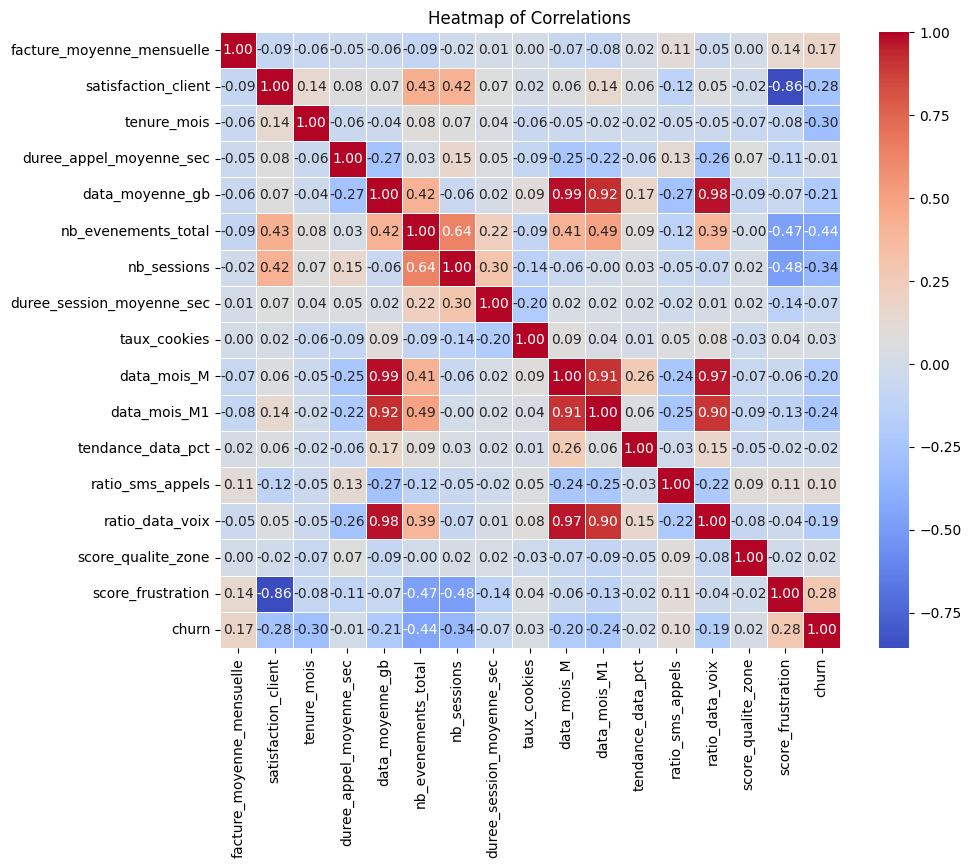

In [342]:
num_cols = ['facture_moyenne_mensuelle', 
    'satisfaction_client', 
    'tenure_mois',  
    'duree_appel_moyenne_sec',  
    'data_moyenne_gb', 
    'nb_evenements_total', 
    'nb_sessions', 
    'duree_session_moyenne_sec',  
    'taux_cookies',  
    'data_mois_M', 
    'data_mois_M1', 
    'tendance_data_pct', 
    'ratio_sms_appels', 
    'ratio_data_voix', 
    'score_qualite_zone', 
    'score_frustration',
    'churn']
num_target = data[num_cols]
correlations = num_target.corr(method = 'spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Heatmap of Correlations')
plt.show()

La heatmap révèle des corrélations quasi-parfaites entre features encore présentes dans X donc notamment :

data_mois_M ↔ data_mois_M1  0.91  Redondance forte

data_moyenne_gb ↔ data_mois_M   0.99   Redondance quasi-totale

data_mois_M ↔ ratio_data_voix   0.97    Redondance quasi-totale

data_moyenne_gb ↔ ratio_data_voix0.98Redondance quasi-totale

Suite à ceà nous avons décider de ne garder que le ratio_data_voix car il nous permet de connaître les habitudes de consomation des clients et de supprimer data_mois_M et data_mois_M1

In [343]:
# === SUPPRESSION REDONDANCES RÉVÉLÉES PAR LA HEATMAP ===
# data_mois_M  : r=0.99 avec data_moyenne_gb
# data_mois_M1 : r=0.92 avec data_moyenne_gb

cols_a_supprimer_heatmap = ['data_mois_M', 'data_mois_M1']

cols_supprimees = [c for c in cols_a_supprimer_heatmap if c in X.columns]
X = X.drop(columns=cols_supprimees)

print(f"Colonnes supprimées : {cols_supprimees}")
print(f"Matrice X — dimensions après correction : {X.shape}")
print(f"\nFeatures restantes :")
for c in X.columns:
    print(f"  {c}")

Colonnes supprimées : ['data_mois_M', 'data_mois_M1']
Matrice X — dimensions après correction : (300, 27)

Features restantes :
  genre_client
  type_abonnement
  plan_tarifaire
  moyen_paiement
  facture_moyenne_mensuelle
  satisfaction_client
  consentement_marketing
  optout_marketing
  tenure_mois
  duree_appel_moyenne_sec
  data_moyenne_gb
  nb_evenements_total
  nb_sessions
  duree_session_moyenne_sec
  taux_cookies
  recence_session_jours
  zone_reseau_principale
  qualite_signal_dominante
  churn
  data_manquante
  satisfaction_manquante
  reclamation_manquante
  tendance_data_pct
  ratio_sms_appels
  ratio_data_voix
  score_qualite_zone
  score_frustration


Dans cette étape, nous procèderons au travers de graphiques univariés à une visualition de la distribution

In [344]:
print("Colonnes catégorielles dans X :")
print(X.select_dtypes(include=['object', 'category']).columns.tolist())

print("\nColonnes binaires (int mais catégorielles) :")
cols_binaires = [c for c in X.columns if X[c].dropna().isin([0, 1]).all()]
print(cols_binaires)

Colonnes catégorielles dans X :
['genre_client', 'type_abonnement', 'plan_tarifaire', 'moyen_paiement', 'zone_reseau_principale', 'qualite_signal_dominante']

Colonnes binaires (int mais catégorielles) :
['consentement_marketing', 'optout_marketing', 'churn', 'data_manquante', 'satisfaction_manquante', 'reclamation_manquante']


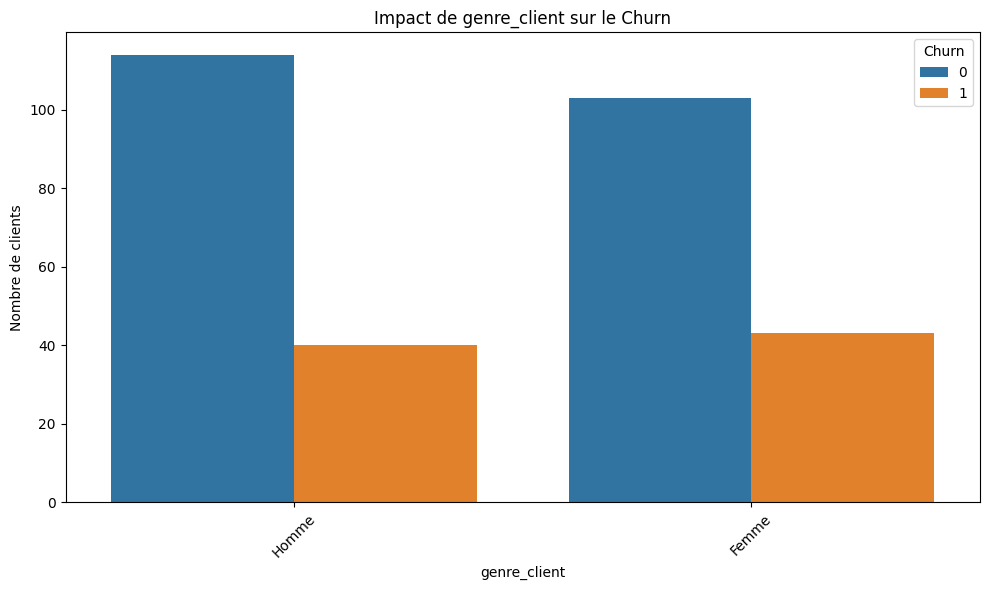

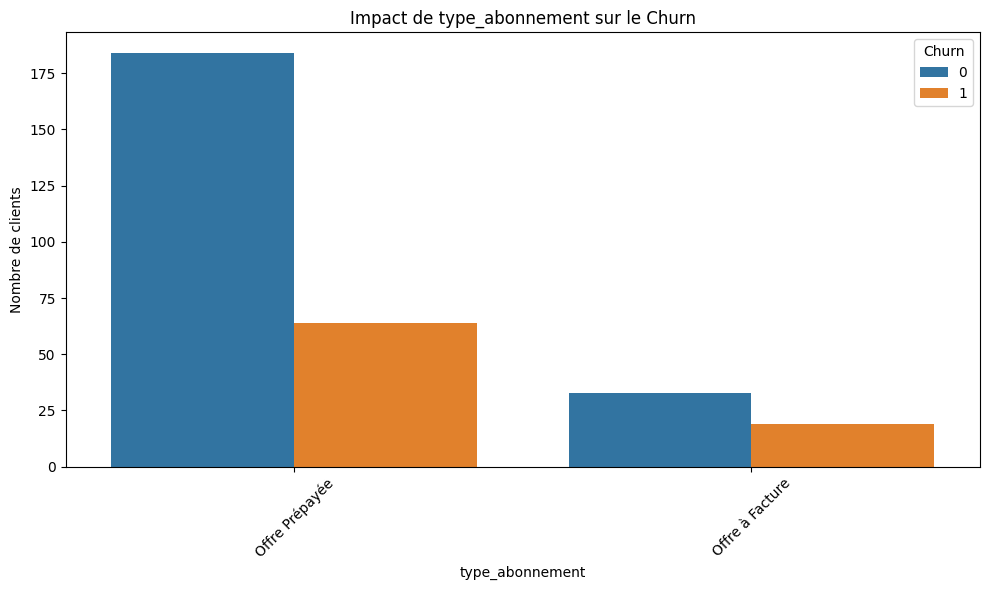

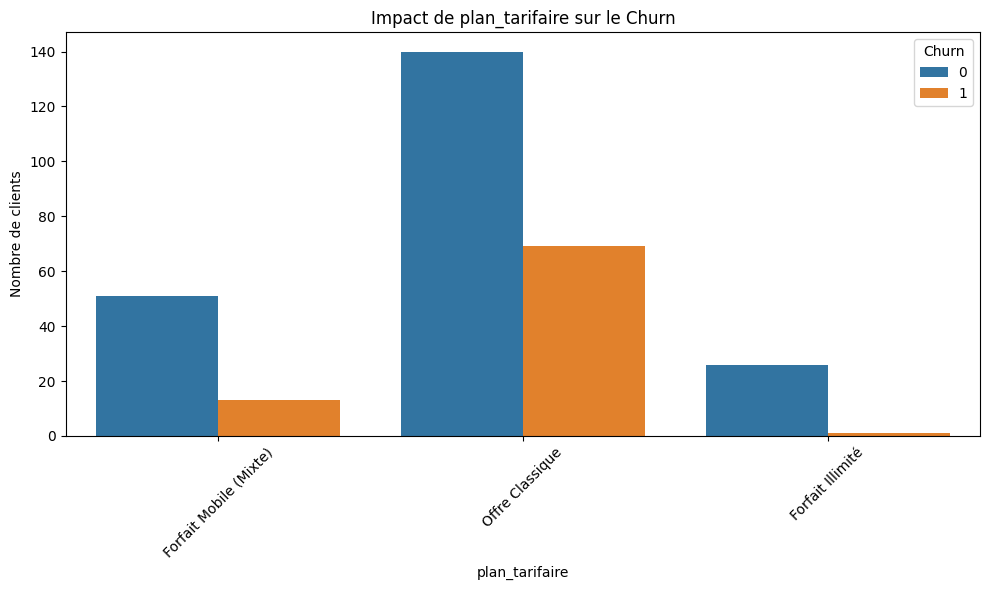

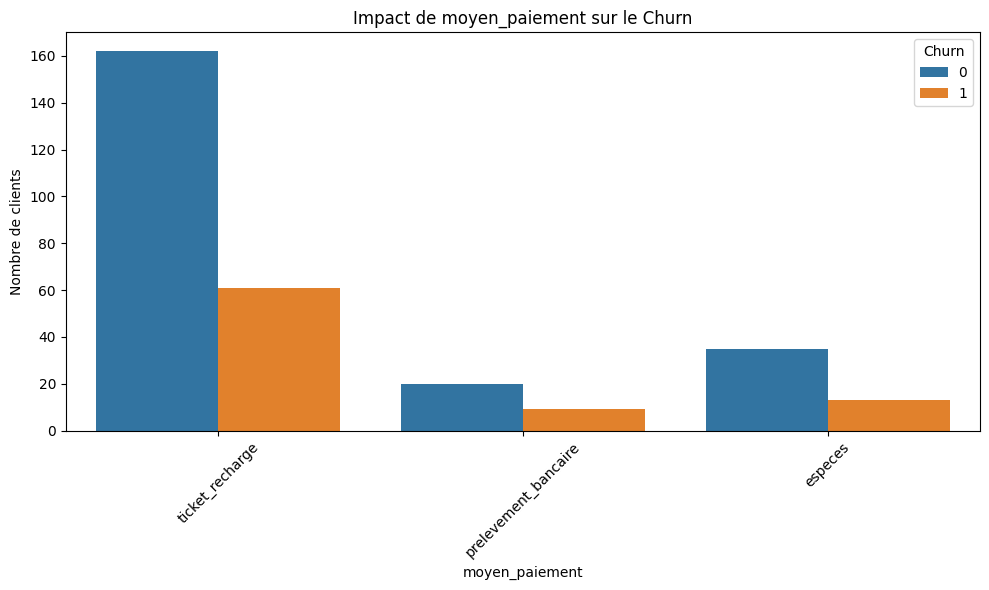

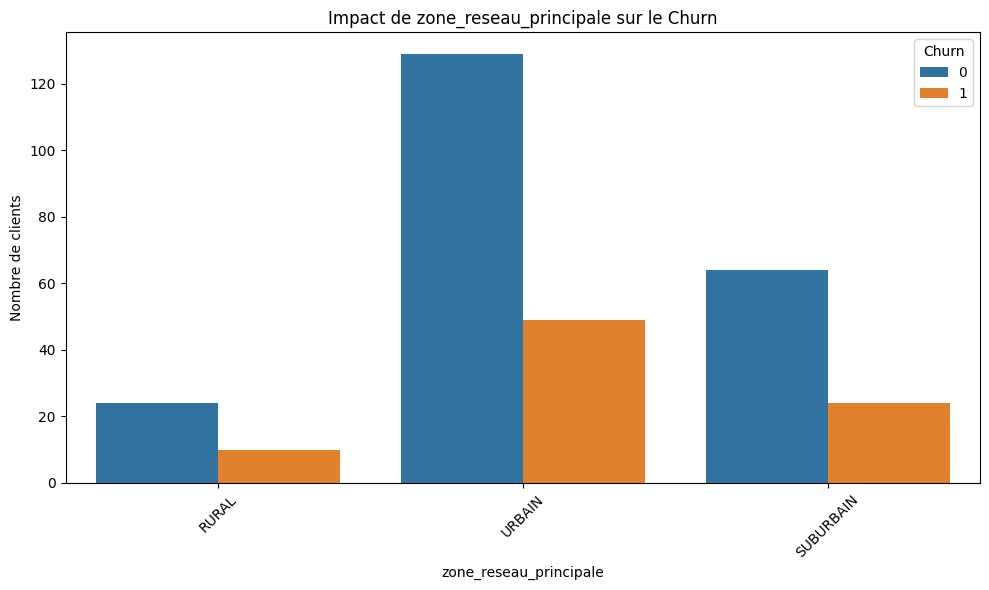

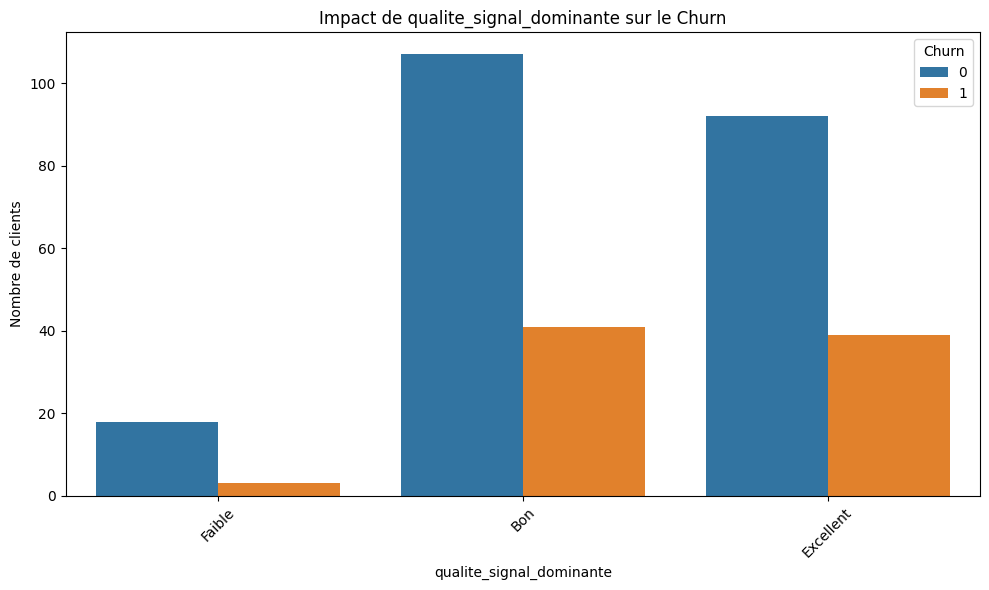

In [345]:
# Liste des colonnes catégorielles
categorical_cols = ['genre_client', 'type_abonnement', 'plan_tarifaire', 'moyen_paiement', 'zone_reseau_principale', 'qualite_signal_dominante' ]

# Graphiques countplot pour chaque colonne catégorielle
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=col, hue='churn')
    plt.title(f"Impact de {col} sur le Churn")
    plt.xlabel(col)
    plt.ylabel('Nombre de clients')
    plt.legend(title='Churn', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [349]:
# Vérification et recréation des flags si absents de df
if 'flag_offre_data' not in df.columns:
    df['flag_offre_data'] = (df['data_moyenne_gb'] > 0).astype(int)
    print("flag_offre_data recréé")

if 'flag_offre_voix' not in df.columns:
    df['flag_offre_voix'] = (df['duree_appel_moyenne_sec'] > 0).astype(int)
    print("flag_offre_voix recréé")

print("Répartition flag_offre_data :", df['flag_offre_data'].value_counts().to_dict())
print("Répartition flag_offre_voix :", df['flag_offre_voix'].value_counts().to_dict())

flag_offre_data recréé
flag_offre_voix recréé
Répartition flag_offre_data : {0: 212, 1: 88}
Répartition flag_offre_voix : {1: 258, 0: 42}


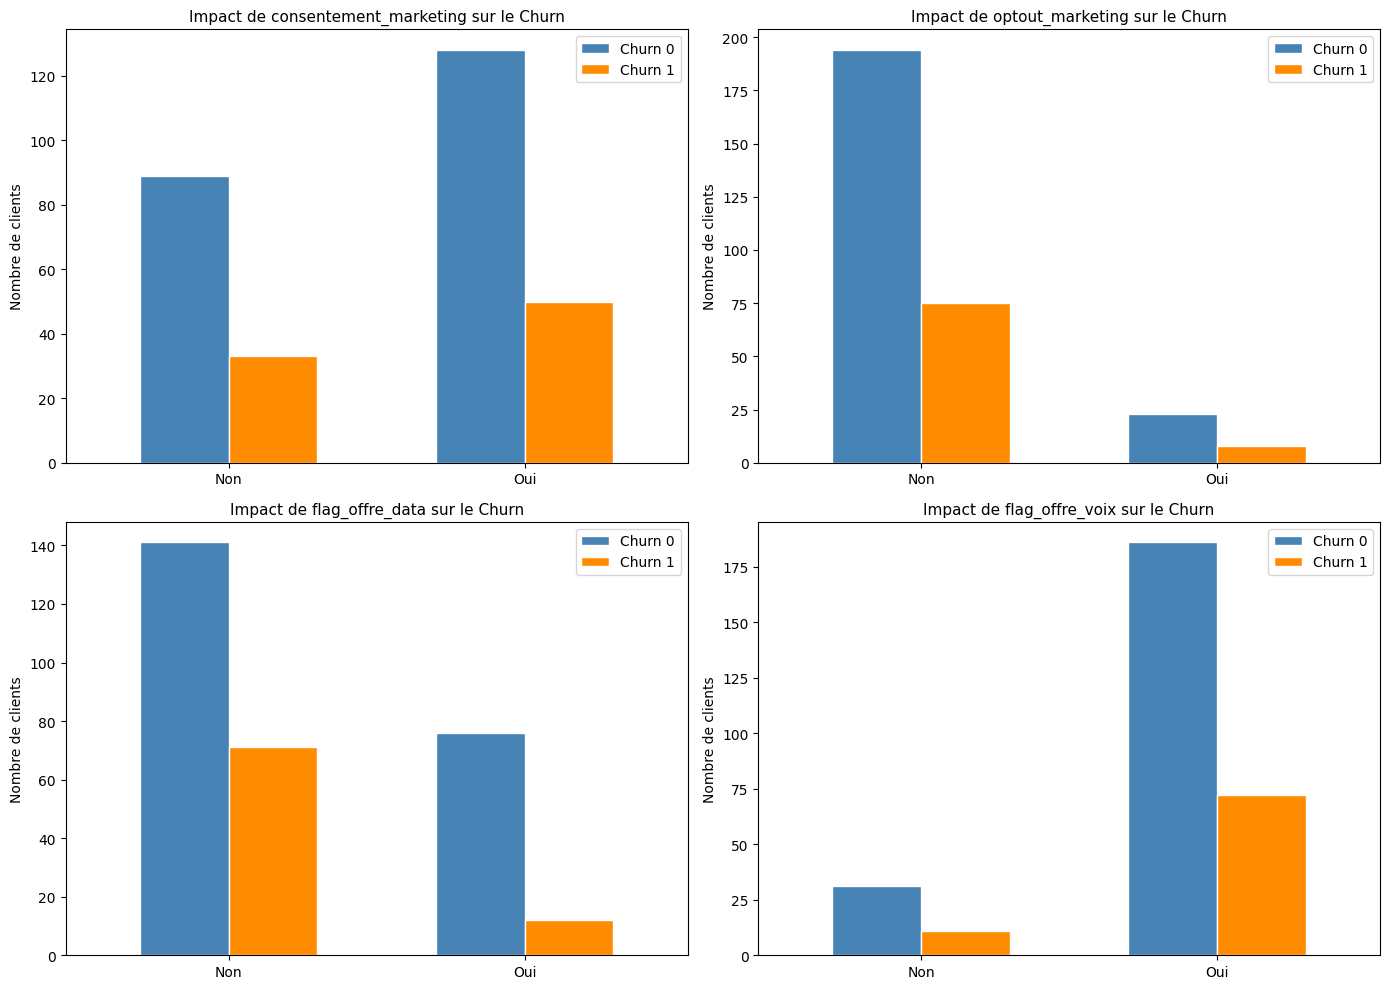

In [351]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cols_binaires = [
    'consentement_marketing', 
    'optout_marketing',
    'flag_offre_data',
    'flag_offre_voix'
]

for ax, col in zip(axes, cols_binaires):
    # Convertir en string proprement pour éviter le bug nan
    temp = df[[col, 'churn']].copy()
    temp[col] = temp[col].astype(float).astype('Int64').astype(str)
    temp[col] = temp[col].map({'0': 'Non', '1': 'Oui'})
    
    ct = temp.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct.columns = ['Actif', 'Churné']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'],
            edgecolor='white', width=0.6)
    ax.set_title(f'Impact de {col} sur le Churn', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Nombre de clients')
    ax.set_xticklabels(['Non', 'Oui'], rotation=0)
    ax.legend(['Churn 0', 'Churn 1'])

plt.tight_layout()
plt.show()

In [354]:
# === SÉLECTION FORMELLE DES VARIABLES POUR HISTOGRAMMES ===
# Critère : |coefficient de Spearman| avec churn, top 6 retenues

cols_numeriques = [
    'facture_moyenne_mensuelle', 'satisfaction_client', 'tenure_mois',
    'duree_appel_moyenne_sec', 'data_moyenne_gb', 'nb_evenements_total',
    'nb_sessions', 'duree_session_moyenne_sec', 'taux_cookies',
    'tendance_data_pct', 'ratio_sms_appels', 'ratio_data_voix',
    'score_qualite_zone', 'score_frustration'
]

spearman_churn = df[cols_numeriques + ['churn']].corr(
    method='spearman')['churn'].drop('churn')

top_variables = spearman_churn.abs().sort_values(ascending=False)

print("Classement formel par |Spearman| avec churn :")
print(top_variables.round(3).to_string())
print(f"\nVariables sélectionnées pour histogrammes (top 6) :")
print(top_variables.head(6).index.tolist())

Classement formel par |Spearman| avec churn :
nb_evenements_total          0.444
nb_sessions                  0.336
tenure_mois                  0.296
score_frustration            0.281
satisfaction_client          0.277
data_moyenne_gb              0.209
ratio_data_voix              0.189
facture_moyenne_mensuelle    0.174
ratio_sms_appels             0.103
duree_session_moyenne_sec    0.073
taux_cookies                 0.031
tendance_data_pct            0.023
score_qualite_zone           0.020
duree_appel_moyenne_sec      0.008

Variables sélectionnées pour histogrammes (top 6) :
['nb_evenements_total', 'nb_sessions', 'tenure_mois', 'score_frustration', 'satisfaction_client', 'data_moyenne_gb']


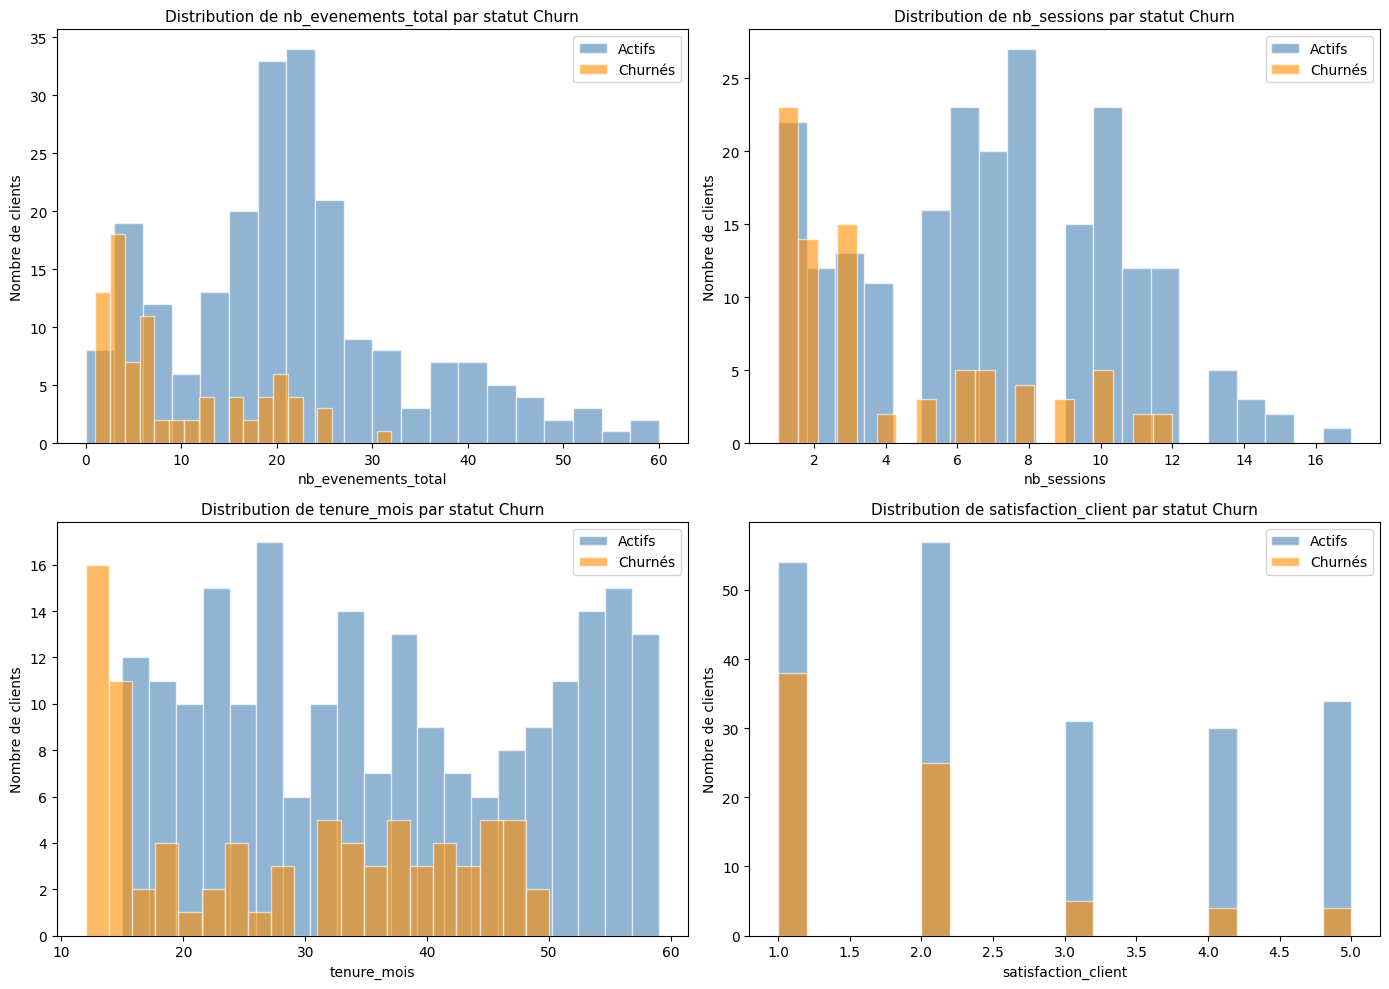

In [ ]:
import matplotlib.pyplot as plt

cols_histo = [
    'nb_evenements_total', 'nb_sessions', 'tenure_mois', 'score_frustration',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_histo):
    for churn_val, label, color in [(0, 'Actifs', 'steelblue'), (1, 'Churnés', 'darkorange')]:
        subset = df[df['churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    
    ax.set_title(f'Distribution de {col} par statut Churn', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre de clients')
    ax.legend()

plt.tight_layout()
plt.show()

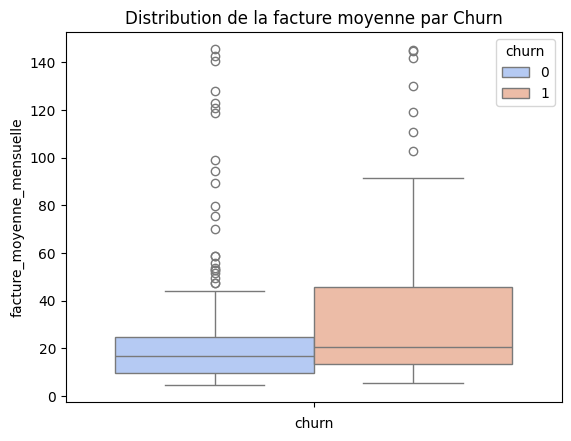

In [355]:
# Boxplot pour comparer la distribution des factures mensuelles (MonthlyCharges) entre les clients churn (1) et non-churn (0)
sns.boxplot(data=data, hue='churn', y='facture_moyenne_mensuelle', palette='coolwarm')
plt.title('Distribution de la facture moyenne par Churn')
plt.xlabel('churn')
plt.ylabel('facture_moyenne_mensuelle')
plt.show()

Le boxplot de la facture moyenne mensuelle révèle une asymétrie structurelle entre les deux groupes. Si les médianes restent relativement proches (17 DT pour les actifs contre 21 DT pour les churnés), la dispersion interquartile des churnés est près de deux fois supérieure, avec un troisième quartile à 45 DT contre 25 DT pour les clients fidèles. Ce différentiel de variance confirme que le risque d'attrition est davantage lié à l'hétérogénéité et l'imprévisibilité de la facturation qu'à son niveau absolu.

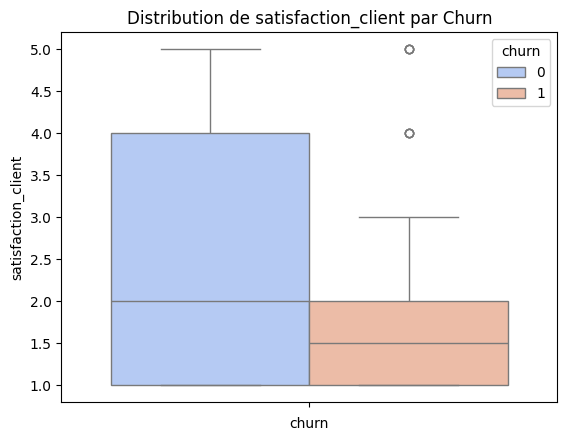

In [358]:
# Boxplot pour comparer la distribution des factures mensuelles (MonthlyCharges) entre les clients churn (1) et non-churn (0)
sns.boxplot(data=data, hue='churn', y='satisfaction_client', palette='coolwarm')
plt.title('Distribution de satisfaction_client par Churn')
plt.xlabel('churn')
plt.ylabel('satisfaction_client')
plt.show()

Les outliers à 4/5 chez les churnés sont des clients satisfaits qui partent quand même — probablement pour des raisons tarifaires, pas relationnelles. C'est rare mais cohérent avec ton analyse "rejet tarifaire".

Pour cette dernière phase de l'analyse exploratoire, nous procèderons à une analyse multivariée

In [ ]:
# Nuage de points pour explorer la relation entre tenure (durée d'abonnement) et MonthlyCharges (factures mensuelles)
# Les points sont colorés en fonction de la variable Churn pour observer les différences entre clients restants et partants
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Tenure in Months', y='Monthly Charge', hue='Churn Label', palette='coolwarm', alpha=0.7)
plt.title('Relation entre tenure et MonthlyCharges (coloré par Churn)')
plt.xlabel('tenure (mois)')
plt.ylabel('MonthlyCharges')
plt.legend(title='Churn', loc='upper right')
plt.show()

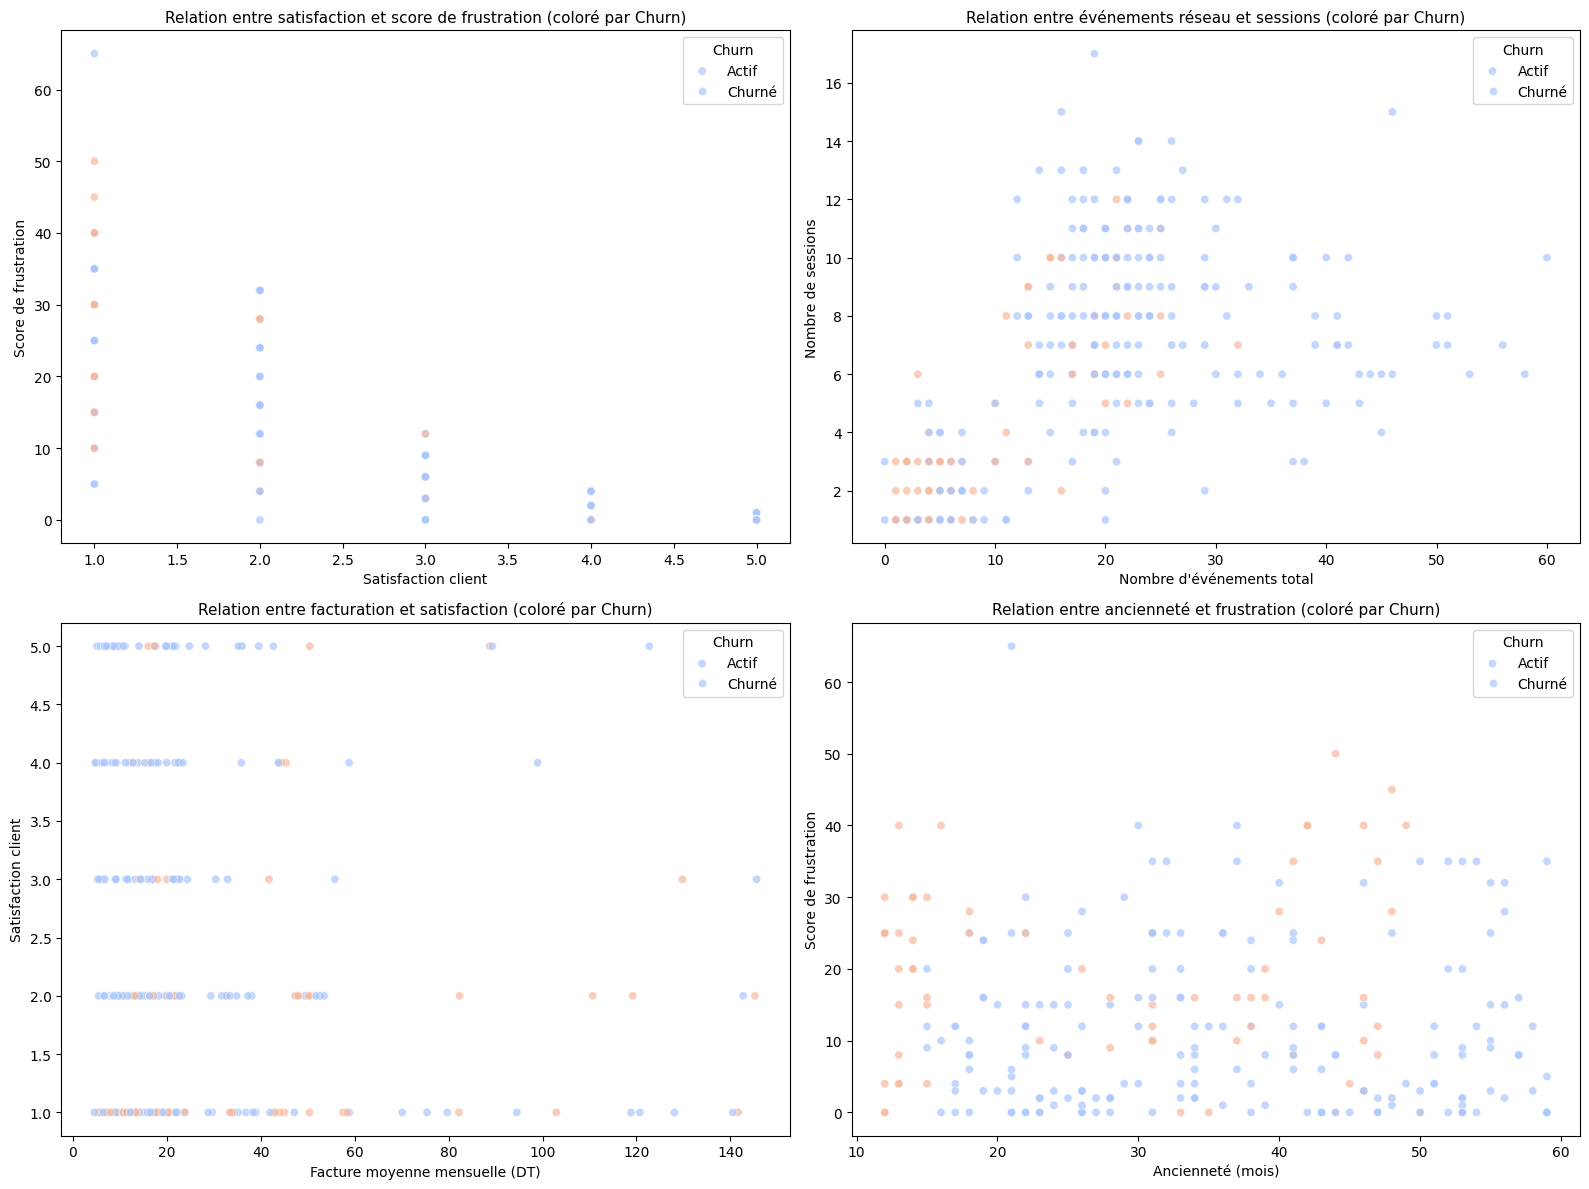

In [362]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

nuages = [
    ('satisfaction_client', 'score_frustration',
     'Relation entre satisfaction et score de frustration (coloré par Churn)',
     'Satisfaction client', 'Score de frustration'),
    ('nb_evenements_total', 'nb_sessions',
     'Relation entre événements réseau et sessions (coloré par Churn)',
     'Nombre d\'événements total', 'Nombre de sessions'),
    ('facture_moyenne_mensuelle', 'satisfaction_client',
     'Relation entre facturation et satisfaction (coloré par Churn)',
     'Facture moyenne mensuelle (DT)', 'Satisfaction client'),
    ('tenure_mois', 'score_frustration',
     'Relation entre ancienneté et frustration (coloré par Churn)',
     'Ancienneté (mois)', 'Score de frustration'),
]

for ax, (x, y, titre, xlabel, ylabel) in zip(axes.flatten(), nuages):
    sns.scatterplot(
        data=df, x=x, y=y,
        hue='churn',
        palette='coolwarm',
        alpha=0.7,
        ax=ax
    )
    ax.set_title(titre, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title='Churn', labels=['Actif', 'Churné'], loc='upper right')

plt.tight_layout()
plt.show()

In [363]:
cols_admin = [
    'client_id', 'nom_client', 'adresse_email', 'num_tel_mobile',
    'adresse_physique', 'identifiant_national', 'date_naissance',
    'date_debut_abonnement', 'date_consentement',
    'latitude_moyenne', 'longitude_moyenne',
]

cols_leakage = [
    'recence_cdr_jours',
    'churn',              # ← ajout critique
]

cols_vif = [
    'tenure_jours',           # ← jours exclu, mois conservé
    'nb_appels',
    'sms_total',
    'nb_evenements_data_cdr',
    'nb_reclamations',
                              # ← nb_evenements_total conservé
]

cols_redondance_totale = [
    'duree_appel_totale_sec',
    'data_totale_gb',
    'duree_session_totale_sec',  # une seule fois
    'data_mois_M',
    'data_mois_M1',
]

cols_a_exclure = cols_admin + cols_leakage + cols_vif + cols_redondance_totale
cols_a_exclure += ['statut_actif']

X = df.drop(columns=[c for c in cols_a_exclure if c in df.columns])
y = df['churn']

# Vérifications
assert 'churn' not in X.columns, "ERREUR : churn dans X !"
assert 'flag_offre_data' in X.columns, "ERREUR : flag_offre_data absent de X !"
assert 'flag_offre_voix' in X.columns, "ERREUR : flag_offre_voix absent de X !"

print(f"Features retenues : {X.shape[1]}")
print(f"Variable cible    : churn ({y.sum()} churné / {len(y)} total)")
print(f"\nFeatures X :")
for c in X.columns:
    print(f"  {c}")

Features retenues : 28
Variable cible    : churn (83 churné / 300 total)

Features X :
  genre_client
  type_abonnement
  plan_tarifaire
  moyen_paiement
  facture_moyenne_mensuelle
  satisfaction_client
  consentement_marketing
  optout_marketing
  tenure_mois
  duree_appel_moyenne_sec
  data_moyenne_gb
  nb_evenements_total
  nb_sessions
  duree_session_moyenne_sec
  taux_cookies
  recence_session_jours
  zone_reseau_principale
  qualite_signal_dominante
  data_manquante
  satisfaction_manquante
  reclamation_manquante
  tendance_data_pct
  ratio_sms_appels
  ratio_data_voix
  score_qualite_zone
  score_frustration
  flag_offre_data
  flag_offre_voix


In [367]:
import os

output_path = os.path.join(os.environ['USERPROFILE'], 'Desktop', 'dataset_modeling.csv')

# Export X + y ensemble pour garder la cible
df_export = X.copy()
df_export['churn'] = y

df_export.to_csv(output_path, index=False)

print(f"Dataset exporté : {output_path}")
print(f"Dimensions : {df_export.shape[0]} lignes × {df_export.shape[1]} colonnes")
print(f"dont {X.shape[1]} features + 1 cible (churn)")
print(f"Churn : {y.sum()} / {len(y)} ({y.mean()*100:.1f}%)")

Dataset exporté : C:\Users\Paul Adrien\Desktop\dataset_modeling.csv
Dimensions : 300 lignes × 29 colonnes
dont 28 features + 1 cible (churn)
Churn : 83 / 300 (27.7%)
